 Training And Testing Available Data

In [6]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

%matplotlib inline

In [7]:
import pandas as pd
import csv

chunks = []
use_cols = ['abstract', 'authors', 'references', 'title', 'venue', 'year', 'n_citation']

try:
    # Using error_bad_lines (or on_bad_lines) and quoting to handle malformed data
    reader = pd.read_csv('dblp-v10.csv',
                         usecols=use_cols,
                         chunksize=50000,
                         engine='python',
                         on_bad_lines='skip',
                         quoting=csv.QUOTE_MINIMAL)

    for i, chunk in enumerate(reader):
        chunk = chunk.drop_duplicates()
        chunks.append(chunk)
        if i >= 5: # Process 300k rows to stay within memory limits
            break

    df = pd.concat(chunks, ignore_index=True)
    df = df.drop_duplicates()
    print(f'Successfully loaded {len(df)} rows.')
    display(df.head())
except Exception as e:
    print(f'Error loading data: {e}')
    # Fallback to a simpler read if the above fails
    df = pd.read_csv('dblp-v10.csv', nrows=100000, on_bad_lines='skip')
    print('Loaded fallback dataset (first 100k rows).')

Error loading data: unexpected end of data
Loaded fallback dataset (first 100k rows).


**DBLP Citation Count Vs Publication Year**

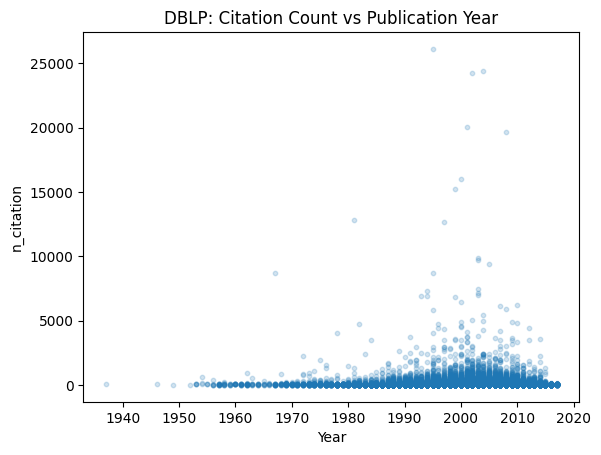

In [8]:
df_sample = df.drop_duplicates().copy()
df_sample['year'] = pd.to_numeric(df_sample['year'], errors='coerce')
df_sample['n_citation'] = pd.to_numeric(df_sample['n_citation'], errors='coerce')
df_sample = df_sample.dropna(subset=['year', 'n_citation']).copy()
plt.scatter(df_sample['year'], df_sample['n_citation'], alpha=0.2, s=10)
plt.xlabel('Year')
plt.ylabel('n_citation')
plt.title('DBLP: Citation Count vs Publication Year')
plt.show()

<p style='color:purple'><b>The approach we are going to use here is to split available data in two sets</b></p>
<ol>
<b>
<li>Training: We will train our model on this dataset</li>
<li>Testing: We will use this subset to make actual predictions using trained model</li>
</b>
</ol>
<p style='color:purple'><b>The reason we don't use same training set for testing is because our model has seen those samples before, using same samples for making predictions might give us wrong impression about accuracy of our model.</b></p>

In [9]:
import pandas as pd
import numpy as np

def count_items(value):
    if pd.isna(value) or value == '':
        return 0
    text = str(value).strip()
    if text in ('[]', 'nan', 'None'):
        return 0
    try:
        if text.startswith('[') and text.endswith(']'):
            items = text.strip('[]').split(',')
            return len([i for i in items if i.strip()])
    except:
        pass
    return 1 if text else 0

# Ensure error-free data: handle missing values and duplicates
# We use the 'df' loaded in the previous step
clean_df = df.drop_duplicates().copy()

# Filter for required columns for modeling
required_cols = ['year', 'n_citation', 'title']
clean_df = clean_df.dropna(subset=required_cols).copy()

# Fill text fields with empty strings
for col in ['abstract', 'authors', 'references', 'venue']:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].fillna('')

# Convert types to numeric
clean_df['year'] = pd.to_numeric(clean_df['year'], errors='coerce')
clean_df['n_citation'] = pd.to_numeric(clean_df['n_citation'], errors='coerce')
clean_df = clean_df.dropna(subset=['year', 'n_citation']).copy()

# Feature engineering as per reference logic
clean_df['reference_count'] = clean_df['references'].apply(count_items)
clean_df['author_count'] = clean_df['authors'].apply(count_items)
clean_df['title_length'] = clean_df['title'].str.len()
clean_df['abstract_length'] = clean_df['abstract'].str.len()
clean_df['venue_length'] = clean_df['venue'].str.len()

# Target variable for Logistic Regression (High vs Low impact)
median_citations = clean_df['n_citation'].median()
clean_df['high_impact'] = (clean_df['n_citation'] > median_citations).astype(int)

print(f'Cleaned records: {len(clean_df)}')
print('Missing values check:\n', clean_df[['year', 'n_citation', 'high_impact']].isna().sum())
display(clean_df.head())

Cleaned records: 100000
Missing values check:
 year           0
n_citation     0
high_impact    0
dtype: int64


,abstract,authors,n_citation,references,title,venue,year,id,reference_count,author_count,title_length,abstract_length,venue_length,high_impact
0,"In this paper, a robust 3D triangular mesh wat...","['S. Ben Jabra', 'Ezzeddine Zagrouba']",50,"['09cb2d7d-47d1-4a85-bfe5-faa8221e644b', '10aa...",A new approach of 3D watermarking based on ima...,international symposium on computers and commu...,2008,4ab3735c-80f1-472d-b953-fa0557fed28b,7,2,61,511,55,0
1,We studied an autoassociative neural network w...,"['Joaquín J. Torres', 'Jesús M. Cortés', 'Joaq...",50,"['4017c9d2-9845-4ad2-ad5b-ba65523727c5', 'b118...",Attractor neural networks with activity-depend...,Neurocomputing,2007,4ab39729-af77-46f7-a662-16984fb9c1db,3,4,93,1021,14,0
2,It is well-known that Sturmian sequences are t...,"['Genevi eve Paquin', 'Laurent Vuillon']",50,"['1c655ee2-067d-4bc4-b8cc-bc779e9a7f10', '2e4e...",A characterization of balanced episturmian seq...,Electronic Journal of Combinatorics,2007,4ab3a4cf-1d96-4ce5-ab6f-b3e19fc260de,7,2,52,711,35,0
3,One of the fundamental challenges of recognizi...,"['Yaser Sheikh', 'Mumtaz Sheikh', 'Mubarak Shah']",221,"['056116c1-9e7a-4f9b-a918-44eb199e67d6', '05ac...",Exploring the space of a human action,international conference on computer vision,2005,4ab3a98c-3620-47ec-b578-884ecf4a6206,10,3,37,1019,43,1
4,This paper generalizes previous optimal upper ...,"['Efraim Laksman', 'Håkan Lennerstad', 'Magnus...",0,"['01a765b8-0cb3-495c-996f-29c36756b435', '5dbc...",Generalized upper bounds on the minimum distan...,Ima Journal of Mathematical Control and Inform...,2015,4ab3b585-82b4-4207-91dd-b6bce7e27c4e,9,3,67,201,51,0


**Looking at the plot and the cleaned data, we will use logistic regression because the target is binary: papers with citations above the median versus papers below the median.**

In [10]:
X = clean_df[['year', 'reference_count', 'author_count', 'title_length', 'abstract_length', 'venue_length']]
y = clean_df['high_impact']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)

In [12]:
X_train

,year,reference_count,author_count,title_length,abstract_length,venue_length
81984,2010,23,2,98,1674,36
660,2003,0,3,48,714,0
12026,2014,8,2,85,955,29
7989,1994,2,1,72,489,38
44904,2004,8,3,110,1189,14
...,...,...,...,...,...,...
67989,2013,0,2,59,0,0
18451,2006,6,3,39,898,33
91107,2000,15,1,82,610,72
21936,2007,5,5,84,774,59


In [13]:
X_test

,year,reference_count,author_count,title_length,abstract_length,venue_length
58921,2009,13,4,85,909,41
56461,2000,8,2,90,875,68
71514,2004,0,5,99,1296,53
53922,2011,1,3,113,862,47
69057,2011,0,3,45,720,35
...,...,...,...,...,...,...
43164,1994,13,2,40,646,27
59386,2002,8,1,101,900,51
52997,2011,0,3,58,699,47
3488,2009,1,2,96,1198,0


In [14]:
y_train

,high_impact
81984,0
660,0
12026,0
7989,0
44904,1
...,...
67989,0
18451,0
91107,0
21936,0


In [15]:
y_test

,high_impact
58921,0
56461,0
71514,0
53922,0
69057,0
...,...
43164,0
59386,0
52997,0
3488,0


**Lets run logistic regression model now**

In [16]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [17]:
X_test

,year,reference_count,author_count,title_length,abstract_length,venue_length
58921,2009,13,4,85,909,41
56461,2000,8,2,90,875,68
71514,2004,0,5,99,1296,53
53922,2011,1,3,113,862,47
69057,2011,0,3,45,720,35
...,...,...,...,...,...,...
43164,1994,13,2,40,646,27
59386,2002,8,1,101,900,51
52997,2011,0,3,58,699,47
3488,2009,1,2,96,1198,0


In [18]:
clf.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0])

In [19]:
y_test

,high_impact
58921,0
56461,0
71514,0
53922,0
69057,0
...,...
43164,0
59386,0
52997,0
3488,0


In [20]:
clf.score(X_test, y_test)

0.8240333333333333

**random_state argument**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, stratify=y)
X_test

,year,reference_count,author_count,title_length,abstract_length,venue_length
58921,2009,13,4,85,909,41
56461,2000,8,2,90,875,68
71514,2004,0,5,99,1296,53
53922,2011,1,3,113,862,47
69057,2011,0,3,45,720,35
...,...,...,...,...,...,...
43164,1994,13,2,40,646,27
59386,2002,8,1,101,900,51
52997,2011,0,3,58,699,47
3488,2009,1,2,96,1198,0


In [22]:
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)
clf.score(X_test, y_test)

0.8240333333333333